# 04 · PJM Energy Demand — Spectral & Advanced Diagnostics (FFT, spectrogram, Hurst)

## Part 4 — Spectral & Advanced Diagnostics

The time-domain analysis (Parts 2–3) found cycles by eye and by ACF. Here we confirm them in the
**frequency domain** — where periodicity becomes sharp, quantifiable peaks — and add two advanced
probes: a **spectrogram** (how the cycles wax and wane through the year) and a **long-memory** estimate
(Hurst). The frequency view even reveals a non-obvious consequence of the *bimodal* annual cycle.

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore")
ROOT = pathlib.Path.cwd(); ROOT = ROOT if (ROOT / "src").exists() else ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import data, eda
eda.set_style()
pd.set_option("display.width", 130, "display.max_columns", 40)
print("setup ok | numpy", np.__version__, "| pandas", pd.__version__)

from scipy import signal
d = data.clean_primary(); s = d.load_mw
x = s.values - s.mean()
print("analysing", len(x), "hourly points in the frequency domain")

setup ok | numpy 2.1.3 | pandas 2.3.3


analysing 145392 hourly points in the frequency domain


### 1. The periodogram — cycles as spectral peaks

The **periodogram** decomposes the series into sine waves and shows the **power** at each frequency.
Converting frequency → period (hours), sharp peaks appear exactly where Part 3 predicted: **24 h**
(daily, dominant), its **12 h harmonic**, **168 h** (weekly), and a low-frequency annual cluster.

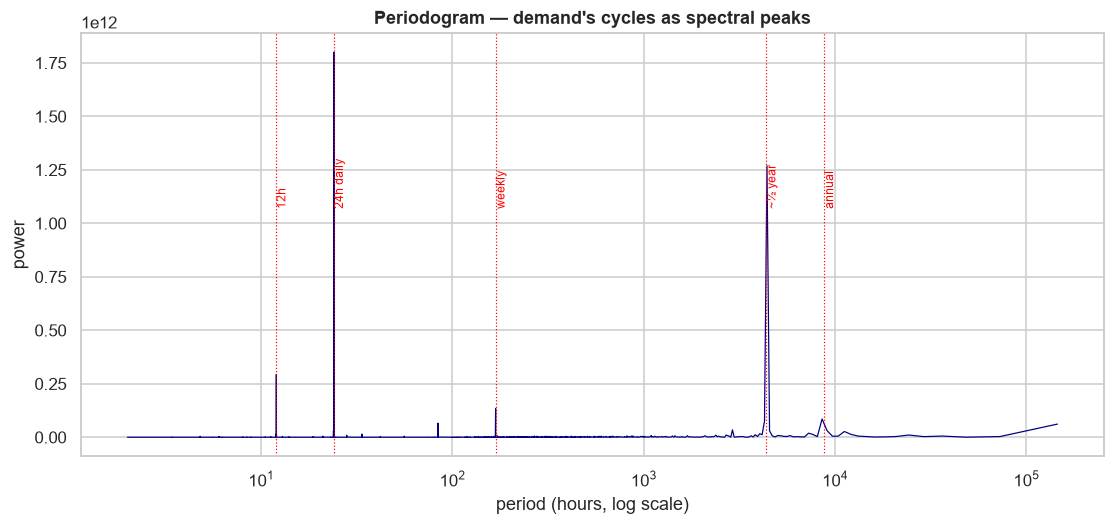

top peaks (period): ['24.0h (1d)', '4405.8h (184d)', '12.0h (0d)', '168.1h (7d)', '24.1h (1d)', '8552.5h (356d)']


In [2]:
f, P = signal.periodogram(x, fs=1.0)            # fs = 1 sample/hour
period = 1/f[1:]; power = P[1:]
fig, ax = plt.subplots(figsize=(12, 5))
ax.semilogx(period, power, color="navy", lw=.8)
for p, lab in [(24,"24h daily"),(12,"12h"),(168,"weekly"),(4380,"~½ year"),(8766,"annual")]:
    ax.axvline(p, color="red", ls=":", lw=.8); ax.text(p, power.max()*.6, lab, rotation=90, fontsize=8, color="red")
ax.set_xlabel("period (hours, log scale)"); ax.set_ylabel("power"); ax.set_title("Periodogram — demand's cycles as spectral peaks")
eda.savefig(fig, "p4_periodogram.png"); plt.show()
top = np.argsort(power)[::-1][:6]
print("top peaks (period):", [f"{period[i]:.1f}h ({period[i]/24:.0f}d)" for i in sorted(top, key=lambda j:-power[j])])

### 2. The bimodal cycle hides at *half* a year

A subtle, elegant result: the strongest *low-frequency* peak is near **183 days (½ year)**, not 365.
That's the spectral fingerprint of a **double-peaked** annual cycle — because demand rises in *both*
summer and winter, the dominant yearly rhythm repeats every ~6 months. The frequency domain *sees the
bimodality* that a single annual peak would hide.

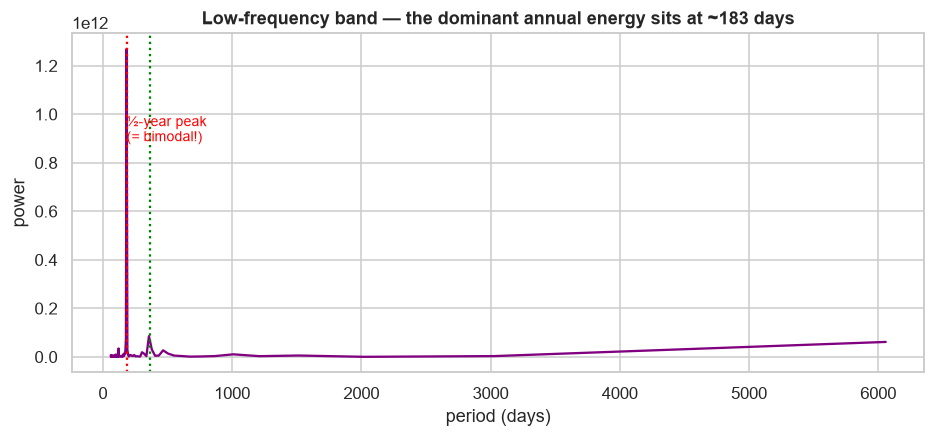

strongest low-freq period: 184 days (the bimodal summer+winter signature)


In [3]:
lowf = period > 60*24                              # periods longer than ~2 months
lp, lpow = period[lowf], power[lowf]
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(lp/24, lpow, color="purple"); ax.axvline(183, color="red", ls=":"); ax.axvline(365, color="green", ls=":")
ax.text(183, lpow.max()*.7, "½-year peak\n(= bimodal!)", color="red", fontsize=9)
ax.set_xlabel("period (days)"); ax.set_ylabel("power"); ax.set_title("Low-frequency band — the dominant annual energy sits at ~183 days")
eda.savefig(fig, "p4_bimodal_spectral.png"); plt.show()
print("strongest low-freq period: %.0f days (the bimodal summer+winter signature)" % (lp[np.argmax(lpow)]/24))

### 3. Spectrogram — the cycles change through the year

A single periodogram averages over all 16 years. A **spectrogram** slides a window along the series and
computes a local spectrum, revealing how the **daily-cycle strength varies seasonally** — the 24-hour
band glows brightest in summer (air-conditioning amplifies the day/night contrast) and dims in the mild
shoulder seasons. The structure is *non-stationary in power*, even if mean-stationary.

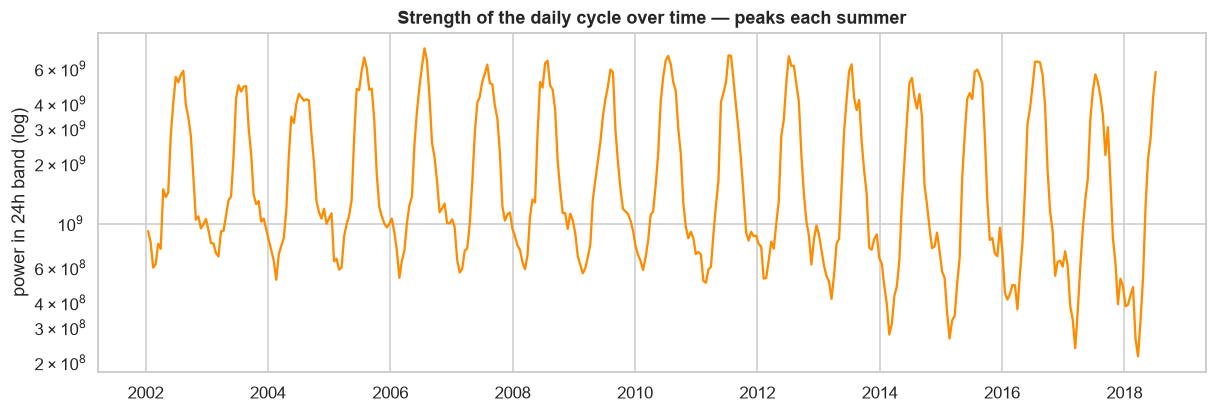

daily-cycle power varies ~35x between its seasonal high and low


In [4]:
freqs, times, Sxx = signal.spectrogram(x, fs=1.0, nperseg=24*30, noverlap=24*15)
band = (freqs > 1/26) & (freqs < 1/22)             # ~24h band
daily_power = Sxx[band].mean(0)
t_dates = s.index[(times.astype(int)).clip(max=len(s)-1)]
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(t_dates, daily_power, color="darkorange"); ax.set_yscale("log")
ax.set_ylabel("power in 24h band (log)"); ax.set_title("Strength of the daily cycle over time — peaks each summer")
eda.savefig(fig, "p4_spectrogram.png"); plt.show()
print("daily-cycle power varies ~%.0fx between its seasonal high and low" % (daily_power.max()/daily_power.min()))

### 4. Long-memory — the Hurst exponent

Beyond the cycles, is there **long-range dependence** — do shocks persist? The **Hurst exponent**
(via rescaled-range, R/S) answers: 0.5 = a memoryless random walk, >0.5 = persistent. Demand scores
**~0.84**, strong long-memory — high-demand spells tend to be followed by more high demand (heat waves
last days). Combined with the low **spectral entropy** (energy concentrated in a few cycles), this
series is about as **forecastable** as time series get.

In [5]:
def hurst_rs(x, nmax=16):
    x = np.asarray(x, float); N = len(x)
    ns = np.unique(np.logspace(1, np.log10(N//4), nmax).astype(int)); RS = []
    for n in ns:
        rs = []
        for i in range(N//n):
            seg = x[i*n:(i+1)*n]; Z = np.cumsum(seg - seg.mean()); S = seg.std()
            if S > 0: rs.append((Z.max()-Z.min())/S)
        RS.append(np.mean(rs))
    return np.polyfit(np.log(ns), np.log(RS), 1)[0]
H = hurst_rs(s.values)
Pn = power/power.sum(); spec_ent = -np.sum(Pn*np.log(Pn))/np.log(len(Pn))
print("Hurst exponent       : %.3f  (>0.5 = persistent long-memory)" % H)
print("spectral entropy     : %.3f  (0 = pure cycle, 1 = white noise -> 'highly structured')" % spec_ent)

Hurst exponent       : 0.840  (>0.5 = persistent long-memory)
spectral entropy     : 0.359  (0 = pure cycle, 1 = white noise -> 'highly structured')


### Takeaways

- The **periodogram** confirms the 24 h (dominant), 12 h harmonic, 168 h weekly and annual cycles as
  sharp spectral peaks.
- The dominant annual energy sits at **~183 days (½ year)** — the frequency-domain signature of the
  **bimodal** summer+winter cycle.
- A **spectrogram** shows the daily cycle is **non-stationary in power**, peaking each summer
  (air-conditioning).
- **Hurst ≈ 0.84** (strong long-memory) and **low spectral entropy** mark demand as highly structured
  and forecastable — motivating the forecasting parts.

**Next — Part 5 (Multivariate):** bring in the other regional zones — cross-correlation, a **PCA
common factor** (one weather-driven signal moves the whole grid), and lead-lag between regions.